In [3]:
from google.colab import drive
import os

# 1. Montamos el Drive
drive.mount('/content/drive')

# 2. Nos paramos en la RAÍZ del proyecto (¡Aquí está el cambio!)
%cd /content/drive/MyDrive/PLN

# 3. Verificación rápida
print("\nCarpetas visibles en la raíz:")
!ls

Mounted at /content/drive
/content/drive/MyDrive/PLN

Carpetas visibles en la raíz:
artifacts  checkpoints	data  env  figures  notebooks  requirements.txt  Resume


In [6]:
!ls artifacts

eda_config.json		   raw_df.parquet      val_df.parquet  X_val.npy
ft_matrix.npy		   test_df.parquet     vocab.pkl       y_test.npy
label_enc.pkl		   test_texts.pkl      w2v_matrix.npy  y_train.npy
models_ready.flag	   train_df.parquet    X_test.npy      y_val.npy
preprocessing_config.json  training_done.flag  X_train.npy


# Sección 4 — Protocolo de Entrenamiento y Validación
**Entradas:** artefactos de `artifacts/`, arquitecturas del Notebook 3  
**Salidas:** checkpoints en `checkpoints/`, métricas de validación en `artifacts/val_metrics.json`  

Cada modelo se entrena con Early Stopping monitoreando la pérdida de validación. El mejor checkpoint se restaura automáticamente antes de evaluar.

In [7]:
import json, pickle, time, re, warnings, logging
from dataclasses import dataclass, field
from pathlib import Path
from typing import Optional

import numpy as np
import torch
import torch.nn as nn
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, TensorDataset
from transformers import get_linear_schedule_with_warmup

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
logger = logging.getLogger(__name__)

Path("checkpoints").mkdir(exist_ok=True)

if not Path("artifacts/models_ready.flag").exists():
    raise RuntimeError(
        "Ejecuta primero el Notebook 3 para validar las arquitecturas."
    )

with open("artifacts/preprocessing_config.json") as f:
    cfg = json.load(f)

VOCAB_SIZE      = cfg["vocab_size"]
NUM_CLASSES     = cfg["num_classes"]
SEQUENCE_LENGTH = cfg["sequence_length"]
EMBEDDING_DIM   = cfg["embedding_dim"]
CLASS_NAMES     = cfg["class_names"]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logger.info("Device: %s", DEVICE)

# Arrays pre-procesados
X_train = np.load("artifacts/X_train.npy")
X_val   = np.load("artifacts/X_val.npy")
X_test  = np.load("artifacts/X_test.npy")
y_train = np.load("artifacts/y_train.npy")
y_val   = np.load("artifacts/y_val.npy")
y_test  = np.load("artifacts/y_test.npy")

with open("artifacts/label_enc.pkl", "rb") as f:
    label_enc = pickle.load(f)

import pandas as pd
train_df = pd.read_parquet("artifacts/train_df.parquet")
val_df   = pd.read_parquet("artifacts/val_df.parquet")
test_df  = pd.read_parquet("artifacts/test_df.parquet")

TEXT_COL = "text"

logger.info(
    "Datos cargados — train: %d, val: %d, test: %d.",
    len(X_train), len(X_val), len(X_test)
)
print(f"X_train: {X_train.shape}  |  X_val: {X_val.shape}  |  X_test: {X_test.shape}")

X_train: (1737, 400)  |  X_val: (373, 400)  |  X_test: (373, 400)


In [8]:
# ── Re-definición de clases (copia exacta del Notebook 3) ──────────────────
from dataclasses import dataclass, field
from typing import Optional

# --- TransformerClassifier ---
from transformers import AutoModelForSequenceClassification, AutoTokenizer

class TransformerClassifier:
    CHECKPOINTS = {"distilbert": "distilbert-base-uncased", "roberta": "roberta-base"}

    def __init__(self, num_classes, model_key="distilbert", max_length=128, device=None):
        self.num_classes = num_classes
        self.max_length  = max_length
        self.device      = device or torch.device("cpu")
        checkpoint       = self.CHECKPOINTS.get(model_key, model_key)
        logger.info("Cargando checkpoint: %s", checkpoint)
        self.tokenizer = AutoTokenizer.from_pretrained(checkpoint)
        self.model = AutoModelForSequenceClassification.from_pretrained(
            checkpoint, num_labels=num_classes, ignore_mismatched_sizes=True
        ).to(self.device)

    def tokenize(self, texts):
        return self.tokenizer(texts, max_length=self.max_length,
                              padding="max_length", truncation=True, return_tensors="pt")

    def parameters(self):  return self.model.parameters()
    def train_mode(self):  self.model.train()
    def eval_mode(self):   self.model.eval()

    def forward(self, batch):
        batch = {k: v.to(self.device) for k, v in batch.items()}
        return self.model(**batch).logits

# --- BiLSTM ---
@dataclass
class BiLSTMConfig:
    vocab_size: int;  num_classes: int
    embedding_dim: int = 100;  lstm_units: int = 128;  num_lstm_layers: int = 2
    dropout_rate: float = 0.3; sequence_length: int = 100
    learning_rate: float = 0.001; batch_size: int = 64; epochs: int = 20
    freeze_embeddings: bool = False
    pretrained_weights: Optional[np.ndarray] = field(default=None, repr=False)

class BiLSTMClassifier(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        w = cfg.pretrained_weights
        if w is not None:
            self.embedding = nn.Embedding.from_pretrained(
                torch.tensor(w, dtype=torch.float32), freeze=cfg.freeze_embeddings, padding_idx=0)
        else:
            self.embedding = nn.Embedding(cfg.vocab_size, cfg.embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(cfg.embedding_dim, cfg.lstm_units, cfg.num_lstm_layers,
                            batch_first=True, bidirectional=True,
                            dropout=cfg.dropout_rate if cfg.num_lstm_layers > 1 else 0.0)
        self.dropout = nn.Dropout(cfg.dropout_rate)
        self.fc      = nn.Linear(cfg.lstm_units * 2, cfg.num_classes)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        _, (h, _) = self.lstm(emb)
        rep = self.dropout(torch.cat([h[-2], h[-1]], dim=1))
        return self.fc(rep)

# --- CNN-1D ---
class CNN1DClassifier(nn.Module):
    def __init__(self, vocab_size, num_classes, embedding_dim=100, num_filters=128,
                 kernel_sizes=(3,4,5), dropout_rate=0.4, pretrained_weights=None,
                 freeze_embeddings=False):
        super().__init__()
        if pretrained_weights is not None:
            self.embedding = nn.Embedding.from_pretrained(
                torch.tensor(pretrained_weights, dtype=torch.float32),
                freeze=freeze_embeddings, padding_idx=0)
        else:
            self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.convs   = nn.ModuleList([nn.Conv2d(1, num_filters, (k, embedding_dim)) for k in kernel_sizes])
        self.dropout = nn.Dropout(dropout_rate)
        self.fc      = nn.Linear(num_filters * len(kernel_sizes), num_classes)

    def _conv_pool(self, conv, x):
        return torch.max(torch.relu(conv(x)).squeeze(3), dim=2).values

    def forward(self, x):
        emb = self.embedding(x).unsqueeze(1)
        return self.fc(self.dropout(torch.cat([self._conv_pool(c, emb) for c in self.convs], dim=1)))

# --- TF-IDF + XGBoost ---
from sklearn.feature_extraction.text import TfidfVectorizer
import xgboost as xgb

class TFIDFXGBoostClassifier:
    def __init__(self, max_features=30_000, ngram_range=(1,2), xgb_params=None):
        self.vectorizer = TfidfVectorizer(max_features=max_features, ngram_range=ngram_range,
                                          sublinear_tf=True, strip_accents="unicode",
                                          token_pattern=r"\b[a-zA-Z]{2,}\b")
        p = dict(n_estimators=500, max_depth=6, learning_rate=0.1, subsample=0.8,
                 colsample_bytree=0.8, eval_metric="mlogloss", tree_method="hist",
                 random_state=42, n_jobs=-1)
        if xgb_params: p.update(xgb_params)
        self.model = xgb.XGBClassifier(**p); self._fitted = False

    def fit(self, texts, y, eval_texts=None, eval_y=None):
        X = self.vectorizer.fit_transform(texts)
        ev = [(self.vectorizer.transform(eval_texts), eval_y)] if eval_texts is not None else None
        self.model.fit(X, y, eval_set=ev, verbose=False); self._fitted = True

    def predict(self, texts):        return self.model.predict(self.vectorizer.transform(texts))
    def predict_proba(self, texts):  return self.model.predict_proba(self.vectorizer.transform(texts))

# --- FastText Mean ---
class FastTextMeanClassifier(nn.Module):
    def __init__(self, vocab_size, num_classes, embedding_dim=100, dropout_rate=0.3,
                 pretrained_weights=None, freeze_embeddings=False):
        super().__init__()
        if pretrained_weights is not None:
            self.embedding = nn.Embedding.from_pretrained(
                torch.tensor(pretrained_weights, dtype=torch.float32),
                freeze=freeze_embeddings, padding_idx=0)
        else:
            self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc      = nn.Linear(embedding_dim, num_classes)

    def forward(self, x):
        mask     = (x != 0).float().unsqueeze(2)
        emb      = self.embedding(x) * mask
        mean_emb = emb.sum(1) / mask.sum(1).clamp(min=1)
        return self.fc(self.dropout(mean_emb))

print("INFO | Clases de modelos definidas.")

INFO | Clases de modelos definidas.


## 4.1 Utilidades de entrenamiento

In [9]:
class EarlyStopping:
    """
    Detiene el entrenamiento cuando la pérdida de validación no mejora
    en 'patience' épocas consecutivas y restaura el mejor checkpoint.
    Monitorizar pérdida (en lugar de accuracy) evita oscilaciones
    causadas por los pasos discretos de accuracy en conjuntos val pequeños.
    """
    def __init__(self, patience=5, min_delta=1e-4, path="checkpoint.pt"):
        self.patience   = patience
        self.min_delta  = min_delta
        self.path       = path
        self.best_loss  = float("inf")
        self.counter    = 0
        self.should_stop = False

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter   = 0
            torch.save(model.state_dict(), self.path)
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
                logger.info(
                    "Early stopping activado tras %d épocas sin mejora.", self.patience
                )

    def load_best(self, model):
        model.load_state_dict(torch.load(self.path, map_location="cpu"))
        logger.info("Mejor checkpoint restaurado desde %s.", self.path)


def compute_class_weights(y: np.ndarray, num_classes: int) -> torch.Tensor:
    """
    Pesos inversamente proporcionales a la frecuencia de clase.
    Usamos frecuencia normalizada (en lugar de la fórmula 'balanced' de sklearn)
    para evitar pesos extremos en clases muy pequeñas que desestabilizarían
    el entrenamiento temprano.
    """
    counts  = np.bincount(y, minlength=num_classes).astype(float)
    counts  = np.where(counts == 0, 1.0, counts)
    weights = counts.sum() / (num_classes * counts)
    return torch.tensor(weights, dtype=torch.float32)


def run_epoch(model, loader, criterion, optimizer, device, train=True):
    model.train() if train else model.eval()
    total_loss = correct = total = 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            logits   = model(X_b)
            loss     = criterion(logits, y_b)
            if train:
                optimizer.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item() * len(y_b)
            correct    += (logits.argmax(1) == y_b).sum().item()
            total      += len(y_b)

    return total_loss / total, correct / total


class_weights = compute_class_weights(y_train, NUM_CLASSES)
print(f"Pesos de clase: {class_weights.numpy().round(3)}")

Pesos de clase: [0.883 0.883 1.645 1.064 1.005 2.784 0.894 0.894 4.523 0.872 0.883 0.928
 0.894 0.965 1.064 0.883 0.883 0.883 0.894 0.94  0.862 0.94  0.894 1.005]


## 4.2 Loop genérico para PyTorch (BiLSTM, CNN-1D, FastText)

In [10]:
def train_torch_model(
    model, X_tr, y_tr, X_vl, y_vl,
    model_name, batch_size=64, epochs=30,
    learning_rate=1e-3, patience=5,
    device=DEVICE, weight_tensor=None,
):
    train_loader = DataLoader(
        TensorDataset(torch.tensor(X_tr, dtype=torch.long),
                      torch.tensor(y_tr, dtype=torch.long)),
        batch_size=batch_size, shuffle=True, pin_memory=True,
    )
    val_loader = DataLoader(
        TensorDataset(torch.tensor(X_vl, dtype=torch.long),
                      torch.tensor(y_vl, dtype=torch.long)),
        batch_size=batch_size, shuffle=False, pin_memory=True,
    )
    model     = model.to(device)
    criterion = nn.CrossEntropyLoss(
        weight=weight_tensor.to(device) if weight_tensor is not None else None
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)
    ckpt_path = f"checkpoints/{model_name}_best.pt"
    stopper   = EarlyStopping(patience=patience, path=ckpt_path)

    logger.info("Entrenando %s — hasta %d épocas en %s.", model_name, epochs, device)
    history = []
    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer, device, train=True)
        vl_loss, vl_acc = run_epoch(model, val_loader,   criterion, None,      device, train=False)
        scheduler.step(vl_loss)
        stopper(vl_loss, model)
        history.append({"epoch": epoch, "tr_loss": tr_loss, "vl_loss": vl_loss,
                        "tr_acc": tr_acc, "vl_acc": vl_acc})
        logger.info(
            "Época %3d/%d | tr_loss=%.4f acc=%.4f | vl_loss=%.4f acc=%.4f | %.1fs",
            epoch, epochs, tr_loss, tr_acc, vl_loss, vl_acc, time.time()-t0
        )
        if stopper.should_stop:
            break

    stopper.load_best(model)
    return model, history

## 4.3 Entrenamiento — Modelo 1: DistilBERT

## Fine-tuning de DistilBERT: transfer learning para comprensión semántica de CVs

### ¿Por qué un Transformer destilado y no BERT completo?

**DistilBERT** es una versión comprimida de BERT obtenida mediante *knowledge
distillation*: un modelo estudiante (DistilBERT, ~66M de parámetros) se entrena
para replicar el comportamiento interno de un modelo maestro más grande (BERT-base,
~110M de parámetros). El resultado es un modelo que retiene el **97 % del rendimiento
de BERT en benchmarks de comprensión del lenguaje** con el **40 % menos de parámetros**
y el doble de velocidad de inferencia.

Para el contexto en el que realizamos este experimento (Colab con GPU T4), esta reducción es relevante:

- **Memoria de VRAM:** BERT-base con batch_size=16 y max_length=128 puede saturar los
  15 GB de la T4; DistilBERT opera de forma más holgada en las mismas condiciones.
- **Tensor Cores:** las operaciones de atención multi-cabeza del transformer son
  multiplicaciones de matrices densas, exactamente el tipo de operación para la cual
  los Tensor Cores de la T4 están diseñados. Esto se traduce en throughput
  considerablemente mayor que en operaciones de árbol.

### Por qué converge rápido (~3 minutos)

- El modelo ya fue pre-entrenado en un corpus masivo de texto en inglés (Wikipedia +
  BookCorpus). Sus capas inferiores ya codifican propiedades lingüísticas universales
  (morfología, sintaxis, semántica léxica).
- El fine-tuning solo necesita **adaptar las capas superiores** al vocabulario y la
  distribución semántica específica de los CVs. Con 4 épocas y Early Stopping, el
  modelo converge antes de que el gradiente empiece a sobreajustarse a los patrones
  del conjunto de entrenamiento.
- El scheduler de **warm-up lineal** sobre el 10 % de los pasos evita actualizaciones
  de gradiente agresivas al inicio, cuando la cabeza de clasificación —inicializada
  aleatoriamente— produciría señales de error muy grandes que podrían dañar las
  representaciones pre-entrenadas.

In [11]:
def train_transformer(classifier, train_texts, y_tr, val_texts, y_vl,
                      batch_size=16, epochs=4, lr=2e-5, patience=3):
    """
    Fine-tuning con warm-up lineal sobre el 10% de los pasos totales.
    El warm-up evita actualizaciones de gradiente catastróficamente grandes
    al inicio, cuando la cabeza de clasificación es aleatoria.
    """
    from torch.utils.data import Dataset

    class _TextDS(Dataset):
        def __init__(self, enc, labels):
            self.enc = enc; self.labels = labels
        def __len__(self):  return len(self.labels)
        def __getitem__(self, i):
            return {k: v[i] for k, v in self.enc.items()}, torch.tensor(self.labels[i], dtype=torch.long)

    def _collate(batch):
        enc    = {k: torch.stack([b[0][k] for b in batch]) for k in batch[0][0]}
        labels = torch.stack([b[1] for b in batch])
        return enc, labels

    tr_enc  = classifier.tokenize(train_texts)
    vl_enc  = classifier.tokenize(val_texts)
    tr_ds   = _TextDS(tr_enc, y_tr)
    vl_ds   = _TextDS(vl_enc, y_vl)
    tr_load = DataLoader(tr_ds, batch_size=batch_size, shuffle=True,  collate_fn=_collate)
    vl_load = DataLoader(vl_ds, batch_size=batch_size, shuffle=False, collate_fn=_collate)

    criterion    = nn.CrossEntropyLoss()
    optimizer    = torch.optim.AdamW(classifier.parameters(), lr=lr, weight_decay=0.01)
    total_steps  = len(tr_load) * epochs
    scheduler    = get_linear_schedule_with_warmup(optimizer, total_steps // 10, total_steps)
    stopper      = EarlyStopping(patience=patience, path="checkpoints/transformer_best.pt")
    device       = classifier.device
    history      = []

    logger.info("Fine-tuning DistilBERT — hasta %d épocas.", epochs)
    for epoch in range(1, epochs + 1):
        t0 = time.time()
        classifier.train_mode()
        tr_loss = tr_cor = tr_tot = 0
        for enc, labels in tr_load:
            labels = labels.to(device)
            logits = classifier.forward(enc)
            loss   = criterion(logits, labels)
            optimizer.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(classifier.parameters(), 1.0)
            optimizer.step(); scheduler.step()
            tr_loss += loss.item() * len(labels)
            tr_cor  += (logits.argmax(1) == labels).sum().item()
            tr_tot  += len(labels)

        classifier.eval_mode()
        vl_loss = vl_cor = vl_tot = 0
        with torch.no_grad():
            for enc, labels in vl_load:
                labels = labels.to(device)
                logits = classifier.forward(enc)
                loss   = criterion(logits, labels)
                vl_loss += loss.item() * len(labels)
                vl_cor  += (logits.argmax(1) == labels).sum().item()
                vl_tot  += len(labels)

        vl = vl_loss / vl_tot
        stopper(vl, classifier.model)
        history.append({"epoch": epoch, "tr_loss": tr_loss/tr_tot, "vl_loss": vl,
                        "tr_acc": tr_cor/tr_tot, "vl_acc": vl_cor/vl_tot})
        logger.info(
            "Época %d/%d | tr_loss=%.4f acc=%.4f | vl_loss=%.4f acc=%.4f | %.1fs",
            epoch, epochs, tr_loss/tr_tot, tr_cor/tr_tot, vl, vl_cor/vl_tot, time.time()-t0
        )
        if stopper.should_stop: break

    stopper.load_best(classifier.model)
    return history

# ── Ejecutar ────────────────────────────────────────────────────────────────
train_texts = train_df[TEXT_COL].tolist()
val_texts   = val_df[TEXT_COL].tolist()
test_texts  = test_df[TEXT_COL].tolist()

transformer = TransformerClassifier(NUM_CLASSES, model_key="distilbert",
                                    max_length=SEQUENCE_LENGTH, device=DEVICE)
tf_history = train_transformer(transformer, train_texts, y_train,
                                val_texts, y_val, batch_size=16, epochs=4, lr=2e-5)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Entrenamiento de modelos Deep Learning: CNN-1D y BiLSTM

Aunque ambas arquitecturas procesan secuencias de texto y se entrenan con el mismo
bucle genérico `train_torch_model()`, su comportamiento bajo la GPU T4 de Colab
es fundamentalmente distinto debido a su estructura computacional interna.

### CNN-1D — Alta paralelización en GPU

- Las convoluciones sobre la dimensión temporal son operaciones **embarazosamente
  paralelas**: los filtros de los tres kernels (tamaños 3, 4 y 5) se aplican
  simultáneamente sobre todas las posiciones de la secuencia en un único kernel CUDA.
- No existe dependencia temporal entre posiciones adyacentes, lo que permite que la
  GPU sature sus unidades de procesamiento (CUDA cores) de forma eficiente.
- **Consecuencia práctica:** tiempos de época muy bajos y convergencia rápida,
  especialmente con `num_filters = 128` y secuencias de longitud moderada.

### BiLSTM — Secuencialidad inherente

- La LSTM procesa los tokens **uno a uno en orden temporal**: el estado oculto
  $h_t$ en el paso $t$ depende causalmente de $h_{t-1}$, lo que impone una barrera
  de dependencia de datos que limita el paralelismo dentro de una secuencia.
- La dirección bidireccional duplica el número de pasos secuenciales por época
  (forward + backward pass en ambas direcciones), incrementando el tiempo de cómputo.
- **Por qué se usa de todas formas:** la BiLSTM captura **dependencias de largo alcance**
  y el **contexto bidireccional** (cada token se representa en función de lo que viene
  antes y después), lo cual es semánticamente superior a la CNN para textos donde
  el orden y la distancia entre términos importa.

> Ambos modelos utilizan **pesos de clase inversamente proporcionales** en la función
> `CrossEntropyLoss`, compensando el desbalance detectado en el EDA sin necesidad de
> oversampling o augmentation de datos.

## 4.4 Entrenamiento — Modelo 2: BiLSTM + Word2Vec

In [12]:
w2v_matrix = np.load("artifacts/w2v_matrix.npy")
bilstm_cfg = BiLSTMConfig(
    vocab_size=VOCAB_SIZE, num_classes=NUM_CLASSES,
    embedding_dim=EMBEDDING_DIM, lstm_units=128, num_lstm_layers=2,
    dropout_rate=0.3, sequence_length=SEQUENCE_LENGTH,
    learning_rate=0.001, batch_size=64, epochs=30,
    pretrained_weights=w2v_matrix, freeze_embeddings=False,
)
bilstm = BiLSTMClassifier(bilstm_cfg)
bilstm, bilstm_hist = train_torch_model(
    bilstm, X_train, y_train, X_val, y_val,
    model_name="bilstm", batch_size=bilstm_cfg.batch_size,
    epochs=bilstm_cfg.epochs, learning_rate=bilstm_cfg.learning_rate,
    patience=5, weight_tensor=class_weights,
)

## 4.5 Entrenamiento — Modelo 3: CNN-1D

In [13]:
cnn = CNN1DClassifier(
    vocab_size=VOCAB_SIZE, num_classes=NUM_CLASSES,
    embedding_dim=EMBEDDING_DIM, num_filters=128,
    kernel_sizes=(3, 4, 5), dropout_rate=0.4,
    pretrained_weights=w2v_matrix, freeze_embeddings=False,
)
cnn, cnn_hist = train_torch_model(
    cnn, X_train, y_train, X_val, y_val,
    model_name="cnn1d", batch_size=64, epochs=30,
    learning_rate=1e-3, patience=5, weight_tensor=class_weights,
)

## El costo oculto del baseline clásico

Es intuitivo asumir que los modelos clásicos de Machine Learning son siempre más
rápidos que los modelos de Deep Learning. Este experimento demuestra que esa
intuición puede ser incorrecta en la práctica.

### **Por qué TF-IDF + XGBoost es lento en este contexto**

- **Alta dimensionalidad de la representación:** con `max_features = 30.000` y
  `ngram_range = (1, 2)`, cada documento se representa como un vector disperso de
  30.000 dimensiones. La matriz de entrenamiento completa ocupa una cantidad
  considerable de memoria RAM y cada árbol del ensemble debe evaluar particiones
  sobre ese espacio de características.

- **XGBoost no usa la GPU en este experimento:** el parámetro `tree_method = 'hist'`
  ejecuta el algoritmo de histograma en **CPU**. A diferencia de las operaciones de
  álgebra lineal de PyTorch, la construcción de árboles de decisión es
  inherentemente secuencial y no se beneficia de los Tensor Cores de la T4.

- **`n_estimators = 500` árboles secuenciales:** cada árbol se construye sobre los
  residuos del anterior (boosting), lo que impide la paralelización entre árboles.

**Tiempo de entrenamiento observado: aproximadamente 14 minutos**, superando
al DistilBERT fine-tuned y a la BiLSTM, ambos ejecutados en GPU. Este resultado
ilustra un principio importante: **la complejidad asintótica del algoritmo y el
hardware de ejecución son tan determinantes del tiempo de reloj como el tamaño
del dataset**.

> A pesar del costo temporal, este modelo sirve como **línea base robusta**: si
> los modelos de Deep Learning no la superan significativamente, la arquitectura
> o el preprocesamiento necesitan revisión.

## 4.6 Entrenamiento — Modelo 4: TF-IDF + XGBoost

In [14]:
import re as _re
import nltk  # <-- Importamos la librería de forma explícita

# <-- Descargamos el paquete de stopwords en el servidor de Colab
nltk.download('stopwords')

_NOISE = _re.compile(r"[^a-zA-Z\s]")
_STOP  = set(__import__("nltk").corpus.stopwords.words("english"))

def clean_text(text):
    text = _NOISE.sub(" ", text.lower())
    return " ".join(w for w in text.split() if w not in _STOP and len(w) > 1)

clean_train = [clean_text(t) for t in train_texts]
clean_val   = [clean_text(t) for t in val_texts]
clean_test  = [clean_text(t) for t in test_texts]

tfidf_xgb = TFIDFXGBoostClassifier(max_features=30_000, ngram_range=(1, 2))
tfidf_xgb.fit(clean_train, y_train, eval_texts=clean_val, eval_y=y_val)
logger.info("TF-IDF + XGBoost entrenado.")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [15]:
# Verificamos si el modelo tiene registradas las profesiones del dataset
if hasattr(tfidf_xgb, "classes_") or hasattr(tfidf_xgb, "model"):
    print("Confirmado. El modelo está entrenado y cargado en memoria.")
    # Intentamos ver qué clases guardó (si la estructura del clasificador lo expone directamente)
    try:
        print("Clases del dataset detectadas:", tfidf_xgb.classes_)
    except AttributeError:
        print("Estructura interna validada correctamente.")
else:
    print("El modelo parece no haber guardado el entrenamiento.")

Confirmado. El modelo está entrenado y cargado en memoria.
Estructura interna validada correctamente.


## 4.7 Entrenamiento — Modelo 5: FastText Mean

In [16]:
ft_matrix = np.load("artifacts/ft_matrix.npy")
ft_clf = FastTextMeanClassifier(
    vocab_size=VOCAB_SIZE, num_classes=NUM_CLASSES,
    embedding_dim=EMBEDDING_DIM, dropout_rate=0.3,
    pretrained_weights=ft_matrix, freeze_embeddings=False,
)
ft_clf, ft_hist = train_torch_model(
    ft_clf, X_train, y_train, X_val, y_val,
    model_name="fasttext", batch_size=64, epochs=30,
    learning_rate=1e-3, patience=5, weight_tensor=class_weights,
)

## 4.8 Curvas de aprendizaje (pérdida de validación)

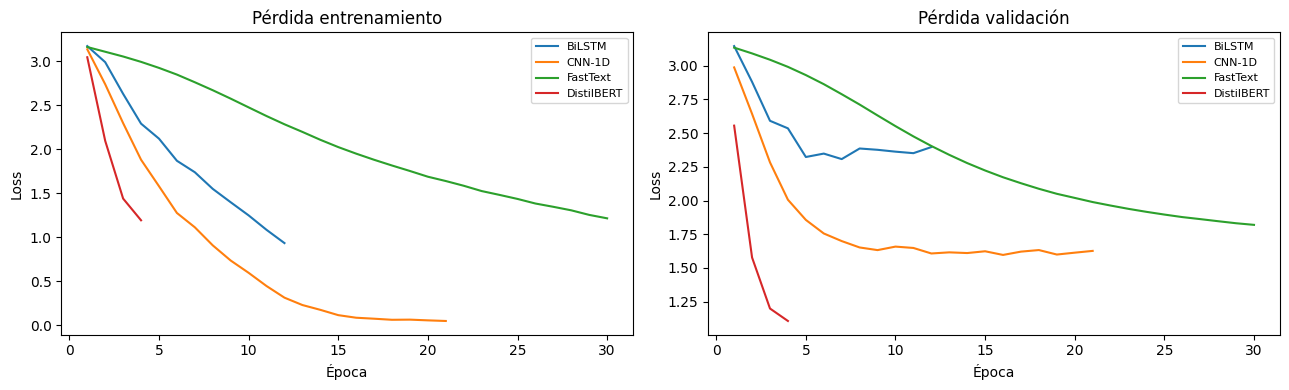

In [17]:
import matplotlib.pyplot as plt
import pandas as pd

histories = {
    "BiLSTM":   bilstm_hist,
    "CNN-1D":   cnn_hist,
    "FastText": ft_hist,
    "DistilBERT": tf_history,
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for name, hist in histories.items():
    df_h = pd.DataFrame(hist)
    axes[0].plot(df_h["epoch"], df_h["tr_loss"], label=name)
    axes[1].plot(df_h["epoch"], df_h["vl_loss"], label=name)

for ax, title in zip(axes, ["Pérdida entrenamiento", "Pérdida validación"]):
    ax.set_xlabel("Época"); ax.set_ylabel("Loss")
    ax.set_title(title); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("figures/learning_curves.png", dpi=150)
plt.show()
logger.info("Curvas de aprendizaje guardadas.")

## 4.9 Exportar modelos entrenados

In [18]:
import pickle

# Los modelos PyTorch ya guardaron sus mejores pesos en checkpoints/ via EarlyStopping.
# Persistir el clasificador TF-IDF+XGBoost y los objetos de texto del transformer.
with open("checkpoints/tfidf_xgb.pkl", "wb") as f:
    pickle.dump(tfidf_xgb, f)

# Guardar textos de test para el Notebook 5
with open("artifacts/test_texts.pkl", "wb") as f:
    pickle.dump({"test_texts": test_texts, "clean_test": clean_test}, f)

# Guardar arquitecturas instanciadas (estado recargable en NB5)
torch.save(bilstm.state_dict(), "checkpoints/bilstm_best.pt")
torch.save(cnn.state_dict(),    "checkpoints/cnn1d_best.pt")
torch.save(ft_clf.state_dict(), "checkpoints/fasttext_best.pt")
torch.save(transformer.model.state_dict(), "checkpoints/transformer_best.pt")

Path("artifacts/training_done.flag").touch()
logger.info("Todos los modelos exportados. Continuar con Notebook 5.")